# 04 · Memory

**What this teaches:** how a graph remembers anything between one `invoke` and the
next.

The example is the memory button on a calculator: a running total that survives
across separate calls.

## The problem

Every `invoke` so far started from nothing. The reducer in 02 accumulated updates
*within* a run, and then the run ended and the state was gone.

A calculator that forgets its total between key presses is not a calculator.

## What is a checkpointer?

From the [persistence docs](https://docs.langchain.com/oss/python/langgraph/persistence#checkpoints):

> **Checkpointers** "persist a thread's graph state as checkpoints. Use them for
> short-term, thread-scoped memory."

- a **checkpoint** is a snapshot of the graph's state at one moment
- a [**thread**](https://docs.langchain.com/oss/python/langgraph/persistence#threads) is
  the series of checkpoints belonging to one conversation, identified by a `thread_id`

The checkpointer is *where* snapshots are stored. The `thread_id` is *which*
calculator they belong to.

In [1]:
import operator
from typing import Annotated

from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from typing_extensions import TypedDict

In [2]:
def show(graph):
    """Draw the graph. Falls back to Mermaid source if mermaid.ink is unreachable."""
    try:
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception:
        print(graph.get_graph().draw_mermaid())

## The graph

One node. It adds `amount` to whatever `total` it finds in state and records the key
press. `total` has **no** reducer — the node computes the new value itself.

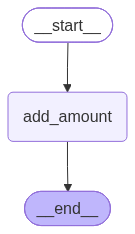

In [3]:
class Calculator(TypedDict):
    total: float
    amount: float
    history: Annotated[list[str], operator.add]


def add_amount(state: Calculator) -> dict:
    total = state.get("total", 0)
    new_total = total + state["amount"]
    return {
        "total": new_total,
        "history": [f"{total} + {state['amount']} = {new_total}"],
    }


builder = StateGraph(Calculator)
builder.add_node("add_amount", add_amount)
builder.add_edge(START, "add_amount")
builder.add_edge("add_amount", END)

show(builder.compile())

## Without a checkpointer

Compile it plainly and press three keys. Each result starts from zero.

In [4]:
forgetful = builder.compile()

for amount in [5, 10, 2]:
    print(forgetful.invoke({"amount": amount}))

{'total': 5, 'amount': 5, 'history': ['0 + 5 = 5']}
{'total': 10, 'amount': 10, 'history': ['0 + 10 = 10']}
{'total': 2, 'amount': 2, 'history': ['0 + 2 = 2']}


## With a checkpointer

The only change is the `compile()` call, plus a `config` naming the thread.

In [5]:
memory = InMemorySaver()
graph = builder.compile(checkpointer=memory)

config = {"configurable": {"thread_id": "1"}}

In [6]:
for amount in [5, 10, 2]:
    print(graph.invoke({"amount": amount}, config))

{'total': 5, 'amount': 5, 'history': ['0 + 5 = 5']}
{'total': 15, 'amount': 10, 'history': ['0 + 5 = 5', '5 + 10 = 15']}
{'total': 17, 'amount': 2, 'history': ['0 + 5 = 5', '5 + 10 = 15', '15 + 2 = 17']}


Three separate `invoke` calls and the total keeps climbing: 5, 15, 17. The graph
loaded the previous checkpoint, ran the node against it, and saved a new one.

Note the two mechanisms doing different jobs: **the checkpointer persists** `total`
from one call to the next, and **the reducer merges** `history` within and across
them. Drop the reducer and history would still persist — it would just be overwritten
each time instead of extended.

## Threads are separate

A different `thread_id` is a different calculator, starting at zero — same graph, same
checkpointer object.

In [7]:
other = {"configurable": {"thread_id": "2"}}

print("thread 2:", graph.invoke({"amount": 100}, other)["total"])
print("thread 1:", graph.invoke({"amount": 1}, config)["total"])

thread 2: 100
thread 1: 18


Thread 2 starts fresh at 100; thread 1 carries on from 17 to 18. In an application the
`thread_id` is a conversation id, a user id, or a session id.

## Reading the saved state

You do not have to run the graph to see a thread's state. `get_state` returns the
latest snapshot, `get_state_history` returns them all, newest first.

In [8]:
snapshot = graph.get_state(config)

print("total:", snapshot.values["total"])
print("next node to run:", snapshot.next)

total: 18
next node to run: ()


In [9]:
history = list(graph.get_state_history(config))

print(f"{len(history)} checkpoints on thread 1, newest first:\n")
for entry in history[:5]:
    print(f"  next={entry.next!s:16} total={entry.values.get('total')}")

12 checkpoints on thread 1, newest first:

  next=()               total=18
  next=('add_amount',)  total=17
  next=('__start__',)   total=17
  next=()               total=17
  next=('add_amount',)  total=15


Every superstep writes a checkpoint, which is what makes replay and time-travel
possible — and, in the next notebook, what lets a graph pause and resume.

## The three checkpointer backends

`InMemorySaver` is one implementation of a shared interface. Swapping backends is a
one-line change.

| Saver | Import | Package | Use for |
| --- | --- | --- | --- |
| `InMemorySaver` | `langgraph.checkpoint.memory` | bundled with `langgraph` | notebooks, tests |
| `SqliteSaver` | `langgraph.checkpoint.sqlite` | `langgraph-checkpoint-sqlite` | local development |
| `PostgresSaver` | `langgraph.checkpoint.postgres` | `langgraph-checkpoint-postgres` | production |

**This notebook uses `InMemorySaver`** — state lives in the Python process and
disappears when the kernel restarts.

```python
# SQLite — installed in this repo, but not used here
from langgraph.checkpoint.sqlite import SqliteSaver

with SqliteSaver.from_conn_string("checkpoints.sqlite") as checkpointer:
    graph = builder.compile(checkpointer=checkpointer)
```

```python
# Postgres — requires `uv add langgraph-checkpoint-postgres`, not installed here
from langgraph.checkpoint.postgres import PostgresSaver

with PostgresSaver.from_conn_string(DB_URI) as checkpointer:
    checkpointer.setup()          # once, creates the tables
    graph = builder.compile(checkpointer=checkpointer)
```

Async variants (`AsyncSqliteSaver`, `AsyncPostgresSaver`) exist for `ainvoke` /
`astream`. See
[checkpointer libraries](https://docs.langchain.com/oss/python/langgraph/persistence#checkpointer-libraries).